# WellSight — DEM Derivatives Walkthrough

This notebook shows **exactly how each terrain layer is generated** from a bare-earth elevation model (DEM). Every formula here is copied from the production builder `notebooks/wellsight/build/_build_derivatives.py` — this is just the same math, one derivative per cell, with a picture after each so you can see what it does.

**How it's organised**
1. **Input cell** — load the DEM (the bare-earth height map) once.
2. **One cell per derivative** — hillshade, slope, roughness, local relief, LRM, TPI (+gradient), openness. Each cell computes the layer and plots it.

> Note on what comes *before* this notebook: the DEM itself — plus DSM, CHM, ground-density and intensity — are made from the raw LiDAR point cloud (`.laz`) with PDAL, in steps 0–3 of `_build_derivatives.py`. Those need the multi-GB point cloud, so this notebook starts from the finished DEM and focuses on the **DEM-derived** layers (steps 4–5 of that script), which is where hillshade / slope / openness / etc. come from.

## 0. Input — load the bare-earth DEM

This is the single input everything below is built from. We also set up the output folder, the project raster helpers (`read_tif` / `write_tif`), and a small `show()` function for plotting. Change `DEM_PATH` to run on a different tile.

DEM: dem_e1423n2235_1m.tif
  grid   : 3454 x 3403 cells
  res    : 1.0 m/cell   CRS: EPSG:6346
  z range: 439.8 .. 658.2 m  (nan: 23.4%)


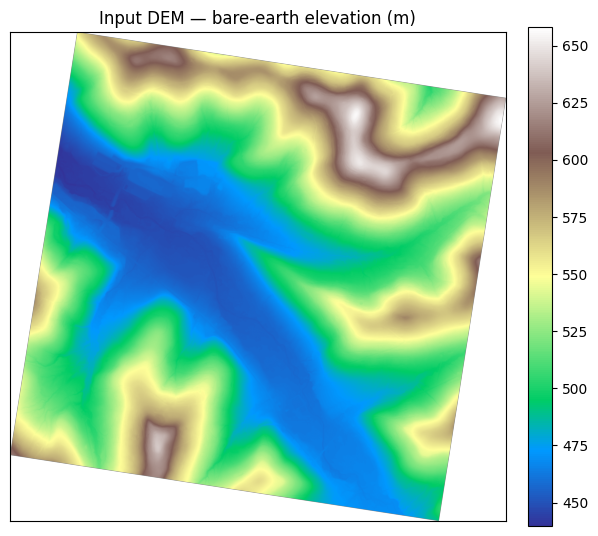

In [1]:
import shutil
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.ndimage import uniform_filter

# --- make the project helpers importable (same ones the build script uses) ---
ROOT = Path(r"C:\Users\colto\Documents\GitHub\lidar_project")
sys.path.insert(0, str(ROOT / "notebooks" / "wellsight"))
from _common import read_tif, write_tif, DST_CRS   # noqa: E402

# --- INPUT: the bare-earth DEM (change this to use a different tile) ---------
DEM_PATH = ROOT / "data/derivatives/data_3x3/northcentral_b19/e1423n2235/dem_e1423n2235_1m.tif"
if not DEM_PATH.exists():
    DEM_PATH = ROOT / "data/derivatives/dem_9t_1m.tif"   # fallback

# --- where this notebook writes its demo outputs (kept separate from real data)
OUT_DIR = ROOT / "data/derivatives/_notebook_demo"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- read the DEM + its geospatial info -------------------------------------
import rasterio
with rasterio.open(DEM_PATH) as r:
    dem = r.read(1).astype(np.float32)
    if r.nodata is not None:
        dem[dem == r.nodata] = np.nan
    transform = r.transform          # maps pixel -> world coords
    res = float(r.res[0])            # cell size in metres (1.0 here)
    crs = r.crs

H, W = dem.shape
print(f"DEM: {DEM_PATH.name}")
print(f"  grid   : {W} x {H} cells")
print(f"  res    : {res} m/cell   CRS: {crs}")
print(f"  z range: {np.nanmin(dem):.1f} .. {np.nanmax(dem):.1f} m  "
      f"(nan: {100*np.isnan(dem).mean():.1f}%)")

# --- tiny plotting helper used by every cell below --------------------------
def show(arr, title, cmap="viridis", vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(7, 7))
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

show(dem, "Input DEM — bare-earth elevation (m)", cmap="terrain")

## 1. Hillshade — simulated sun-shading

Shines a virtual sun across the terrain (from the north-west, 45° up) and shades each slope by how much it faces the light. This is the classic "3-D looking" relief image — mainly for the human eye. Built with **WhiteboxTools** `hillshade(azimuth=315, altitude=45)`.

WhiteboxTools works on files, so we copy the DEM into the output folder, run the tool there, then read the result back.

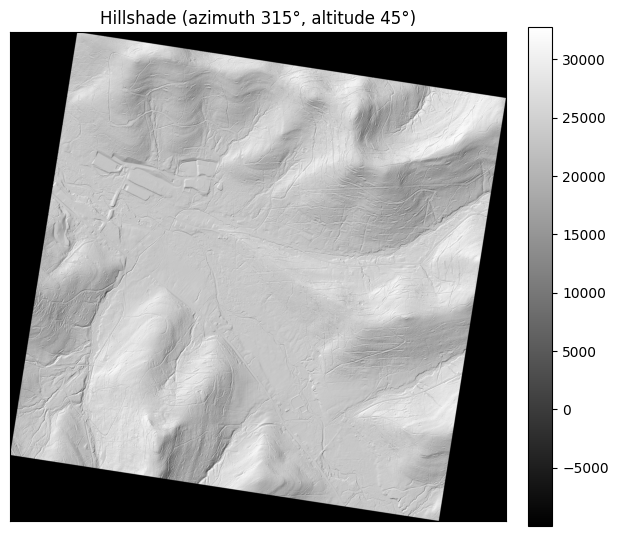

In [2]:
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.set_verbose_mode(False)
wbt.set_working_dir(str(OUT_DIR.resolve()))

# WBT operates on files in its working dir — copy the DEM in once.
dem_local = "dem_input.tif"
shutil.copy2(DEM_PATH, OUT_DIR / dem_local)

wbt.hillshade(dem=dem_local, output="hillshade.tif", azimuth=315.0, altitude=45.0)
hillshade = read_tif(OUT_DIR / "hillshade.tif")
show(hillshade, "Hillshade (azimuth 315°, altitude 45°)", cmap="gray")

## 2. Slope — steepness in degrees

How steep the ground is at each cell, 0° (flat) to 90° (vertical). Well pads are unnaturally flat; natural hillsides aren't. WhiteboxTools `slope(units="degrees")`.

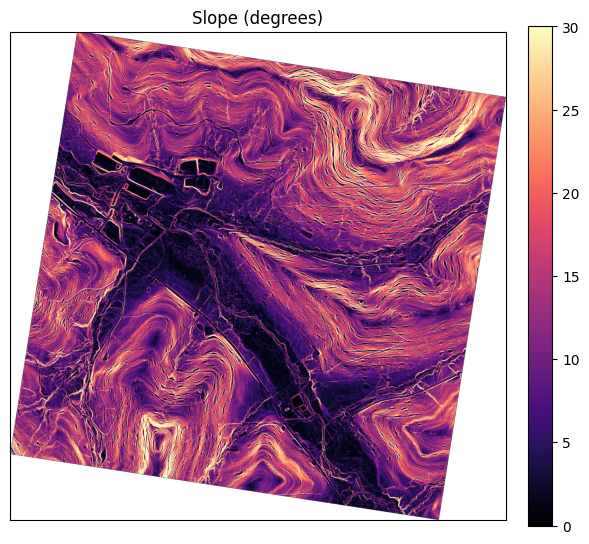

In [3]:
wbt.slope(dem=dem_local, output="slope.tif", units="degrees")
slope = read_tif(OUT_DIR / "slope.tif")
show(slope, "Slope (degrees)", cmap="magma", vmin=0, vmax=30)

## 3. Roughness — local surface texture

The **standard deviation of elevation in a 5×5 window**. Smooth ground gives a low value; bumpy / disturbed ground gives a high one. Pure NumPy — we use convolutions to get the windowed mean and mean-of-squares, then combine them into a variance and take the square root (NaN-aware so tile edges don't leak).

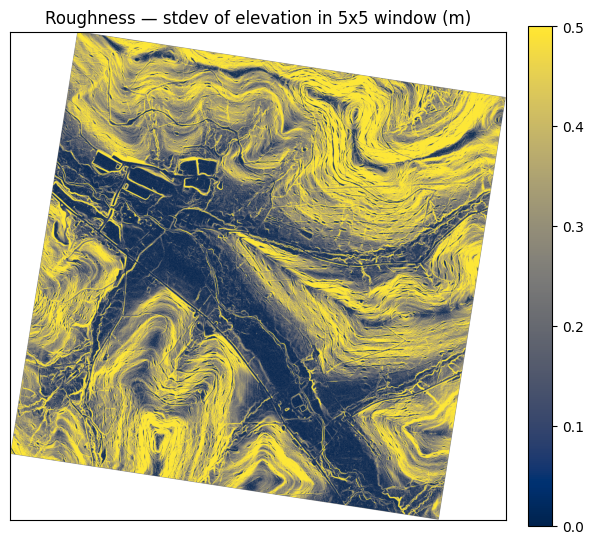

In [4]:
WIN = 5
k = np.ones((WIN, WIN), dtype=np.float32)
v = np.isfinite(dem).astype(np.float32)          # 1 where valid, 0 where NaN
z0 = np.where(v.astype(bool), dem, 0).astype(np.float32)
s  = ndi.convolve(z0,      k, mode="nearest")    # windowed sum of z
s2 = ndi.convolve(z0 * z0, k, mode="nearest")    # windowed sum of z^2
n  = ndi.convolve(v,       k, mode="nearest")    # windowed count of valid cells
var = np.where(n > 1, (s2 - s * s / np.maximum(n, 1)) / np.maximum(n - 1, 1), np.nan)
roughness_5 = np.sqrt(np.clip(var, 0, None)).astype(np.float32)
roughness_5[n < WIN * WIN] = np.nan              # require a full window

write_tif(OUT_DIR / "roughness_5.tif", roughness_5, transform=transform, crs=crs)
show(roughness_5, "Roughness — stdev of elevation in 5x5 window (m)",
     cmap="cividis", vmin=0, vmax=0.5)

## 4. Local relief — height range in a 10 m disk

For each cell, the **highest minus the lowest** elevation within a 10 m radius circle. It measures how much vertical variation sits nearby — small for flat areas, large near banks, pits, and edges. Computed with NaN-aware max- and min-filters over a circular kernel.

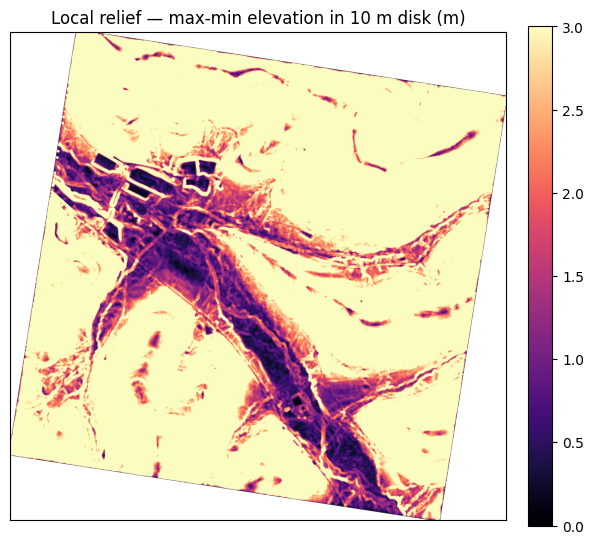

In [5]:
def disk_kernel(r_cells):
    """A circular (disk) footprint of radius r_cells, as a boolean array."""
    r = int(round(r_cells))
    y, x = np.ogrid[-r:r+1, -r:r+1]
    return (x * x + y * y) <= r * r

def _nanmax_disk(a, kernel):
    big = np.where(np.isfinite(a), a, -np.inf)
    out = ndi.maximum_filter(big, footprint=kernel, mode="nearest")
    return np.where(np.isfinite(out), out, np.nan).astype(np.float32)

def _nanmin_disk(a, kernel):
    small = np.where(np.isfinite(a), a, np.inf)
    out = ndi.minimum_filter(small, footprint=kernel, mode="nearest")
    return np.where(np.isfinite(out), out, np.nan).astype(np.float32)

rk = disk_kernel(10 / res)                       # 10 m radius -> cells
local_relief_10 = (_nanmax_disk(dem, rk) - _nanmin_disk(dem, rk)).astype(np.float32)
write_tif(OUT_DIR / "local_relief_10.tif", local_relief_10, transform=transform, crs=crs)
show(local_relief_10, "Local relief — max-min elevation in 10 m disk (m)",
     cmap="magma", vmin=0, vmax=3)

## 5. Local Relief Model (LRM) — small bumps with the big hills removed

**LRM = DEM − (smoothed DEM).** Blur the terrain to estimate the broad landscape, then subtract it; what's left is only the *small* local departures — exactly where faint man-made scars live. The blur radius (the `size`) controls the scale: small sizes catch fine detail, big sizes catch broader features. The production stack uses **lrm_5** and **lrm_25**; here we build all four (3 / 5 / 11 / 25) to show the effect of scale.

C:\Users\colto\AppData\Local\Temp\claude\ipykernel_46576\1185889568.py:7: RuntimeWarning: invalid value encountered in divide
  smooth = np.where(sc > 0, sm / sc, np.nan)              # NaN-aware mean


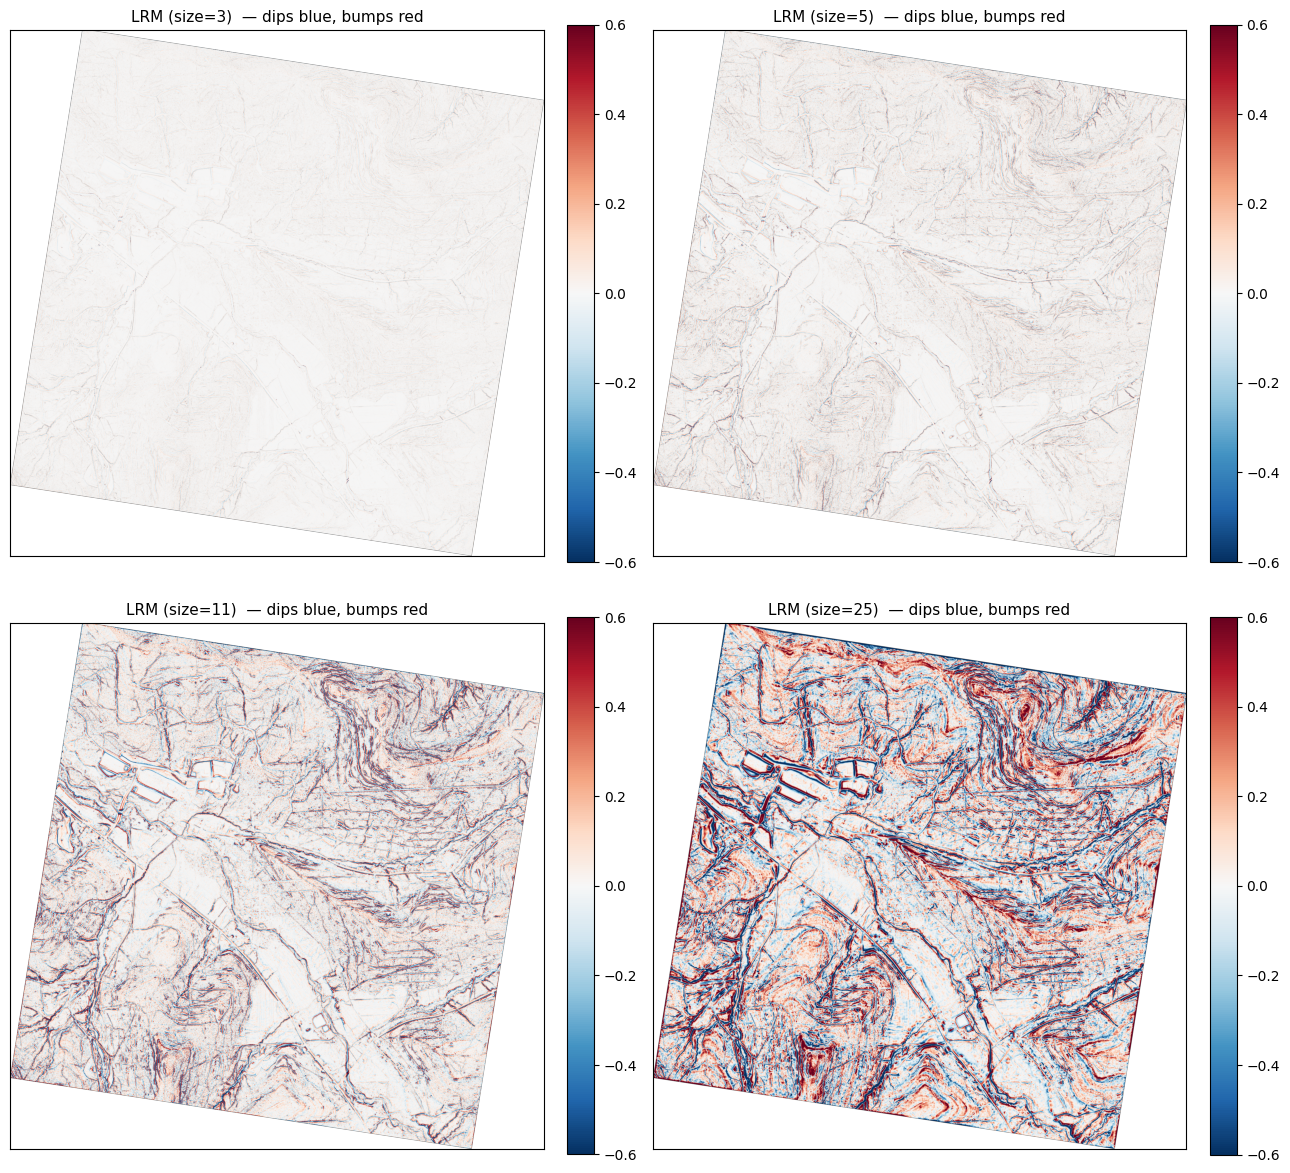

In [6]:
lrm = {}
for size in (3, 5, 11, 25):
    valid = np.isfinite(dem).astype(np.float32)
    z0 = np.where(valid.astype(bool), dem, 0).astype(np.float32)
    sm = uniform_filter(z0,    size=size, mode="nearest")   # blurred sum
    sc = uniform_filter(valid, size=size, mode="nearest")   # blurred count
    smooth = np.where(sc > 0, sm / sc, np.nan)              # NaN-aware mean
    lrm[size] = (dem - smooth).astype(np.float32)
    write_tif(OUT_DIR / f"lrm_{size}.tif", lrm[size], transform=transform, crs=crs)

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, size in zip(axes.ravel(), (3, 5, 11, 25)):
    im = ax.imshow(lrm[size], cmap="RdBu_r", vmin=-0.6, vmax=0.6)
    ax.set_title(f"LRM (size={size})  — dips blue, bumps red", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 6. Topographic Position Index (TPI) — higher or lower than the neighbours

**TPI = DEM − (mean elevation in a disk around the cell).** Positive on ridges / mounds (you sit above your surroundings), negative in gullies / pits (you sit below). We compute it at 5, 15 and 25 m radii. The production stack uses **tpi_05**; we also derive the **gradient of tpi_15** (its magnitude and direction) as edge/flow descriptors.

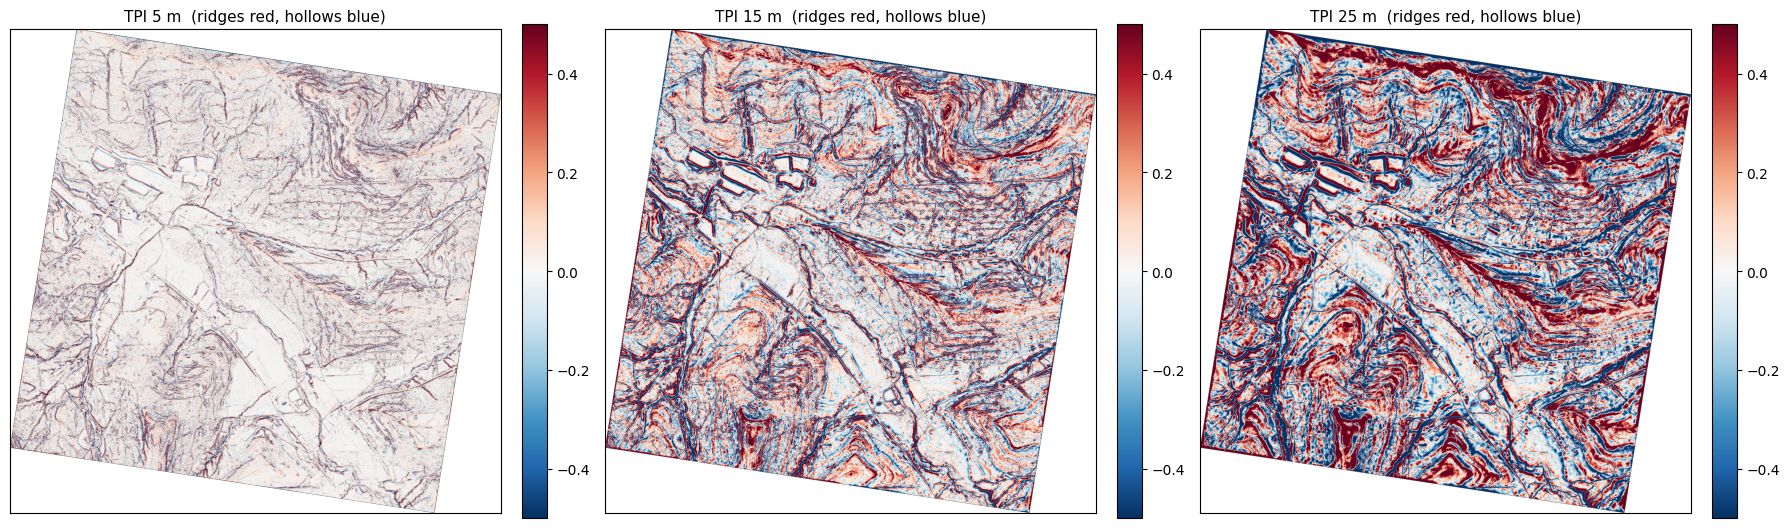

In [7]:
def nanmean_filter(a, kernel):
    """NaN-aware mean of `a` over a boolean `kernel` footprint."""
    valid = np.isfinite(a).astype(np.float32)
    a0 = np.where(valid.astype(bool), a, 0).astype(np.float32)
    kf = kernel.astype(np.float32)
    s = ndi.convolve(a0,    kf, mode="nearest")
    c = ndi.convolve(valid, kf, mode="nearest")
    out = np.full_like(a, np.nan, dtype=np.float32)
    np.divide(s, c, out=out, where=c > 0)
    return out

def tpi(z, r_m):
    return (z - nanmean_filter(z, disk_kernel(r_m / res))).astype(np.float32)

tpi_05 = tpi(dem, 5.0)
tpi_15 = tpi(dem, 15.0)
tpi_25 = tpi(dem, 25.0)
for name, arr in [("tpi_05", tpi_05), ("tpi_15", tpi_15), ("tpi_25", tpi_25)]:
    write_tif(OUT_DIR / f"{name}.tif", arr, transform=transform, crs=crs)

# Gradient of TPI-15: how fast TPI changes, and which way it faces.
gy, gx = np.gradient(tpi_15, res)
tpi_grad_mag = np.hypot(gx, gy).astype(np.float32)
tpi_grad_dir = (np.degrees(np.arctan2(gx, -gy)) % 360).astype(np.float32)
write_tif(OUT_DIR / "tpi_grad_mag.tif", tpi_grad_mag, transform=transform, crs=crs)
write_tif(OUT_DIR / "tpi_grad_dir.tif", tpi_grad_dir, transform=transform, crs=crs)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, arr) in zip(axes, [("TPI 5 m", tpi_05), ("TPI 15 m", tpi_15),
                                  ("TPI 25 m", tpi_25)]):
    im = ax.imshow(arr, cmap="RdBu_r", vmin=-0.5, vmax=0.5)
    ax.set_title(name + "  (ridges red, hollows blue)", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 7. Openness (positive & negative) — how exposed vs. tucked-in a spot is

Openness (Yokoyama 1998) looks outward from each cell along **8 compass directions**, up to 25 cells away, and measures the angle to the sky.

* **Positive openness** is large where a spot is exposed (ridge tops, flat open ground) and small inside depressions.
* **Negative openness** is the mirror image — large inside dips and channels.

This is one of the strongest layers for finding the **depressions and edges** that mark old well pits. The code below is the exact `openness()` function from the build script.

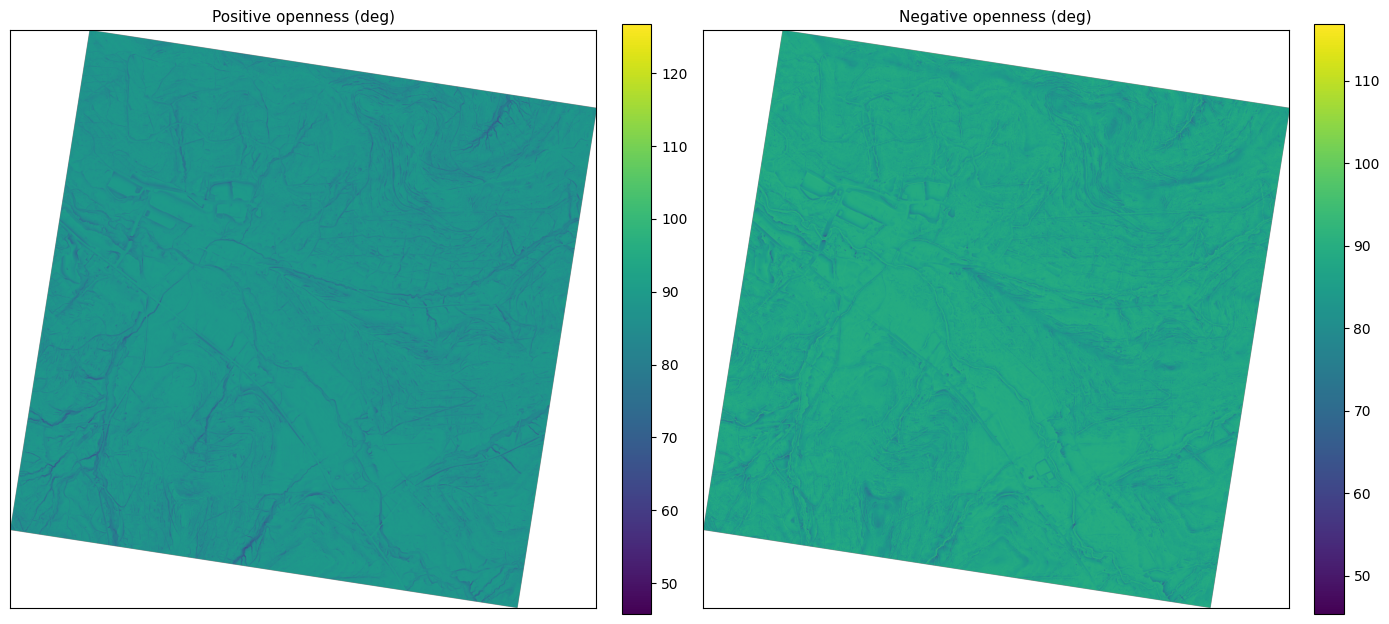

In [8]:
def openness(z, *, L_cells, cellsize):
    """Yokoyama (1998) positive and negative openness over 8 directions."""
    dirs = [(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1),(-1,-1)]
    valid = np.isfinite(z)
    z0 = np.where(valid, z, 0).astype(np.float32)
    phi = np.zeros_like(z, dtype=np.float32)     # accumulates positive openness
    psi = np.zeros_like(z, dtype=np.float32)     # accumulates negative openness
    for dr, dc in dirs:
        step = cellsize * np.hypot(dr, dc)
        mtu = np.full_like(z, -np.inf, dtype=np.float32)   # max up-angle this dir
        mtd = np.full_like(z,  np.inf, dtype=np.float32)   # min down-angle this dir
        for k in range(1, L_cells + 1):
            zs = np.roll(z0,    shift=(dr * k, dc * k), axis=(0, 1))
            vs = np.roll(valid, shift=(dr * k, dc * k), axis=(0, 1))
            # blank out cells that rolled across an edge
            if dr > 0:   vs[:dr*k, :] = False
            elif dr < 0: vs[dr*k:, :] = False
            if dc > 0:   vs[:, :dc*k] = False
            elif dc < 0: vs[:, dc*k:] = False
            ta = np.where(vs, (zs - z0) / (k * step), np.nan).astype(np.float32)
            np.fmax(mtu, ta, out=mtu, where=vs)
            np.fmin(mtd, ta, out=mtd, where=vs)
        phi += (np.pi/2 - np.arctan(np.where(np.isfinite(mtu), mtu, 0))).astype(np.float32)
        psi += (np.pi/2 + np.arctan(np.where(np.isfinite(mtd), mtd, 0))).astype(np.float32)
    phi = np.degrees(phi / 8).astype(np.float32)
    psi = np.degrees(psi / 8).astype(np.float32)
    phi[~valid] = np.nan; psi[~valid] = np.nan
    return phi, psi

openness_pos, openness_neg = openness(dem, L_cells=int(25 / res), cellsize=res)
write_tif(OUT_DIR / "openness_pos.tif", openness_pos, transform=transform, crs=crs)
write_tif(OUT_DIR / "openness_neg.tif", openness_neg, transform=transform, crs=crs)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (name, arr) in zip(axes, [("Positive openness (deg)", openness_pos),
                                  ("Negative openness (deg)", openness_neg)]):
    im = ax.imshow(arr, cmap="viridis")
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## Recap — how this maps to the real pipeline

Every layer above was produced with the **same formula and parameters** as `notebooks/wellsight/build/_build_derivatives.py`. In production they're written into `data/derivatives/<region>/` with a suffix in each filename (e.g. `slope_9t_1m.tif`).

Seven of these derivatives are then stacked, z-scored, and fed to the models as the **7-band feature stack** (see `_instance_common.py :: FEATURE_CHANNELS`):

| # | band | built in cell |
|---|---|---|
| 1 | `lrm_25` | 5 (LRM) |
| 2 | `lrm_5`  | 5 (LRM) |
| 3 | `slope`  | 2 (Slope) |
| 4 | `tpi_05` | 6 (TPI) |
| 5 | `openness_pos` | 7 (Openness) |
| 6 | `openness_neg` | 7 (Openness) |
| 7 | `roughness_11` | 3 (Roughness — production uses radius 11; here we showed 5) |

Hillshade and local-relief are diagnostic / visual layers, not model inputs.

Demo outputs were written to `data/derivatives/_notebook_demo/` (git-ignored by the `data/derivatives/**/*.tif` rule).